# Scripts del proyecto

- <a href='#1'>Script 1: Preparación de datos para entrenamiento</a>
- <a href='#2'>Script 2: Código de Entrenamiento</a>
- <a href='#3'>Script 3: Preparación de Datos de Validación</a>
- <a href='#4'>Script 4. Código de validación</a>
- <a href='#5'>Script 5. Preparación de Datos de Churn (Automatización)</a>
- <a href='#6'>Script 6. Código de Churn (Automatización)</a>

# <a id='s'>Script 1: Preparación de datos para entrenamiento</a>

In [1]:
import numpy as np 
import pandas as pd 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [2]:
telcom = pd.read_csv(r"../data/raw/churn-bigml-train.csv")
telcom_test = pd.read_csv(r"../data/raw/churn-bigml-test.csv")
telcom.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
#Removing correlated and unneccessary columns
col_to_drop = ['State', 'Area code', 'Total day charge', 'Total eve charge', 
               'Total night charge', 'Total intl charge']
   
telcom = telcom.drop(columns = col_to_drop, axis = 1)
# telcom_test = telcom_test.drop(columns = col_to_drop, axis = 1)

#target column
target_col = ["Churn"]

#Separating categorical and numerical columns
#categorical columns
cat_cols = list(set(telcom.nunique()[telcom.nunique()<6].keys().tolist() 
                    + telcom.select_dtypes(include='object').columns.tolist()))
cat_cols = [x for x in cat_cols if x not in target_col]
#numerical columns
num_cols = [x for x in telcom.columns if x not in cat_cols + target_col]
#Binary columns with 2 values
bin_cols = telcom.nunique()[telcom.nunique() == 2].keys().tolist()

#Label encoding Binary columns
le = LabelEncoder()
for i in bin_cols:
    telcom[i] = le.fit_transform(telcom[i])
    # telcom_test[i] = le.transform(telcom_test[i])

#Scaling Numerical columns
std = StandardScaler()
scaled = std.fit_transform(telcom[num_cols])
scaled = pd.DataFrame(scaled, columns=num_cols)

#dropping original values merging scaled values for numerical columns
df_telcom_og = telcom.copy()
telcom = telcom.drop(columns = num_cols, axis = 1)
telcom = telcom.merge(scaled, left_index=True, right_index=True, how = "left")

In [4]:
telcom.columns

Index(['International plan', 'Voice mail plan', 'Churn', 'Account length',
       'Number vmail messages', 'Total day minutes', 'Total day calls',
       'Total eve minutes', 'Total eve calls', 'Total night minutes',
       'Total night calls', 'Total intl minutes', 'Total intl calls',
       'Customer service calls'],
      dtype='object')

In [5]:
telcom.to_csv("../data/processed/telcom_train.csv")

# <a id='2'>Script 2: Código de Entrenamiento</a>

In [6]:
import pandas as pd
from xgboost import XGBClassifier
import pickle

In [7]:
# Cargar la tabla transformada
df = pd.read_csv("../data/processed/telcom_train.csv") #.set_index('ID')
x_train = df.drop(['Churn'],axis=1)
y_train = df[['Churn']]

In [8]:
# Entrenamos el modelo con toda la muestra
xgb_mod=XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
                    colsample_bytree=1, gamma=0, learning_rate=0.9, max_delta_step=0,
                    max_depth=7, min_child_weight=1, n_estimators=100,
                    n_jobs=1, nthread=None, objective='binary:logistic', random_state=0,
                    reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
                    silent=True, subsample=1)
xgb_mod.fit(x_train, y_train)

C:\Users\janic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [23:00:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,0.5
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,1
,colsample_bynode,None
,colsample_bytree,1
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [9]:
# Guardamos el modelo entrenado para usarlo en produccion
filename = '../models/best_model.pkl'
pickle.dump(xgb_mod, open(filename, 'wb'))

# <a id='3'>Script 3: Preparación de Datos de Validación</a>

In [10]:
import numpy as np 
import pandas as pd 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [11]:
telcom_val = pd.read_csv(r"../data/raw/churn-bigml-test.csv")
telcom_val.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [12]:
#Removing correlated and unneccessary columns
col_to_drop = ['State', 'Area code', 'Total day charge', 'Total eve charge', 
               'Total night charge', 'Total intl charge']
   
telcom_val = telcom_val.drop(columns = col_to_drop, axis = 1)
# telcom_test = telcom_test.drop(columns = col_to_drop, axis = 1)

#target column
target_col = ["Churn"]

#Separating categorical and numerical columns
#categorical columns
cat_cols = list(set(telcom_val.nunique()[telcom_val.nunique()<6].keys().tolist() 
                    + telcom_val.select_dtypes(include='object').columns.tolist()))
cat_cols = [x for x in cat_cols if x not in target_col]
#numerical columns
num_cols = [x for x in telcom_val.columns if x not in cat_cols + target_col]
#Binary columns with 2 values
bin_cols = telcom_val.nunique()[telcom_val.nunique() == 2].keys().tolist()

#Label encoding Binary columns
le = LabelEncoder()
for i in bin_cols:
    telcom_val[i] = le.fit_transform(telcom_val[i])
    # telcom_test[i] = le.transform(telcom_test[i])

#Scaling Numerical columns
std = StandardScaler()
scaled = std.fit_transform(telcom_val[num_cols])
scaled = pd.DataFrame(scaled, columns=num_cols)

#dropping original values merging scaled values for numerical columns
telcom_val = telcom_val.drop(columns = num_cols, axis = 1)
telcom_val = telcom_val.merge(scaled, left_index=True, right_index=True, how = "left")

In [13]:
telcom_val.to_csv("../data/processed/telcom_val.csv")

# <a id='4'>Script 4.  Código de validación</a>

In [14]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import *

In [15]:
# Cargar la tabla transformada
df = pd.read_csv("../data/processed/telcom_val.csv")
X_test = df.drop(['Churn'],axis=1)
y_test = df[['Churn']]

In [16]:
# Leemos el modelo entrenado!
filename = '../models/best_model.pkl'
model = pickle.load(open(filename, 'rb'))

In [17]:
# Predecimos sobre el set de datos de implementacion con el modelo entrenado
y_pred_test=model.predict(df.drop(['Churn'],axis=1)) 

In [18]:
## Metricas de validación
def calc_metrics(y_test,y_pred_test):
    cm_test = confusion_matrix(y_test,y_pred_test)
    print("Matriz de confusion: ")
    print(cm_test)
    accuracy_test=accuracy_score(y_test,y_pred_test)
    print("Accuracy: ", accuracy_test)
    precision_test=precision_score(y_test,y_pred_test)
    print("Precision: ", precision_test)
    recall_test=recall_score(y_test,y_pred_test)
    print("Recall: ", recall_test)

In [75]:
def save_plot(title):
    # if fig is None:
    #     fig = plt.gcf()  # Obtener la figura actual
    plt.title(title)
    fig = plt.gcf()
    filename = title.replace(" ", "_").lower()
    fig.savefig('{}'.format(filename), dpi=500)    
    
def plot_confusion_matrix(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"Matriz de Confusión: {type(model).__name__}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Actual")
    return fig
     
def plot_roc_curve(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)
    
    fig, ax = plt.subplots(figsize=(7, 6))

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

    ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax.set_title(f'Curva ROC: {type(model).__name__}')
    ax.legend(loc="lower right")
    ax.grid(True)
    
    return fig

C:\Users\janic\AppData\Local\Temp\ipykernel_10768\2385410574.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_confusion_matrix(model, X_test, y_test).show()


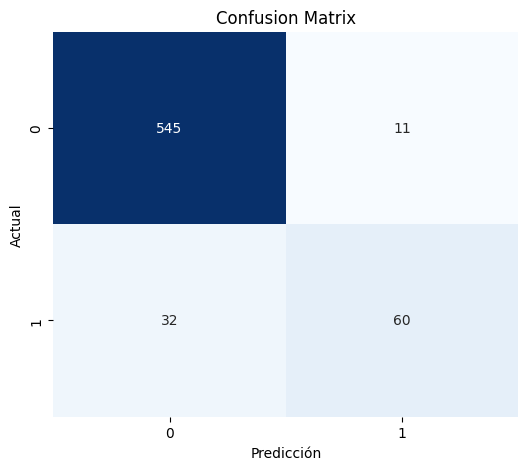

In [76]:
plot_confusion_matrix(model, X_test, y_test).show()
save_plot('Confusion Matrix')

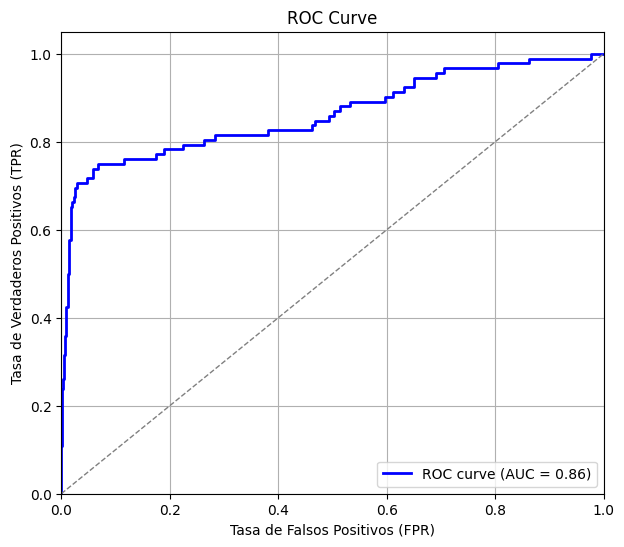

In [77]:
plot_roc_curve(model, X_test, y_test)
save_plot('ROC Curve')

# <a id='5'>Script 5: Preparación de Datos de Churn (Automatización)</a>

In [22]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [23]:
# Leemos la tabla de entrenamiento
df = pd.read_csv("../data/raw/churn-bigml-predict.csv")

In [24]:
#Removing correlated and unneccessary columns
col_to_drop = ['State', 'Area code', 'Total day charge', 'Total eve charge', 
               'Total night charge', 'Total intl charge']
   
df = df.drop(columns = col_to_drop, axis = 1)

#target column
target_col = ["Churn"]

#Separating categorical and numerical columns
#categorical columns
cat_cols = list(set(df.nunique()[df.nunique()<6].keys().tolist() 
                    + df.select_dtypes(include='object').columns.tolist()))
cat_cols = [x for x in cat_cols if x not in target_col]
#numerical columns
num_cols = [x for x in df.columns if x not in cat_cols + target_col]
#Binary columns with 2 values
bin_cols = df.nunique()[df.nunique() == 2].keys().tolist()

#Label encoding Binary columns
le = LabelEncoder()
for i in bin_cols:
    df[i] = le.fit_transform(df[i])

#Scaling Numerical columns
std = StandardScaler()
scaled = std.fit_transform(df[num_cols])
scaled = pd.DataFrame(scaled, columns=num_cols)

#dropping original values merging scaled values for numerical columns
df = df.drop(columns = num_cols, axis = 1)
df = df.merge(scaled, left_index=True, right_index=True, how = "left")

In [25]:
df.to_csv("../data/processed/telcom_churn.csv")

# <a id='6'>Script 6: Código de Churn (Automatización)</a>

In [26]:
import pandas as pd
import pickle

In [27]:
# Cargar la tabla transformada
df = pd.read_csv("../data/processed/telcom_churn.csv")

In [28]:
# Leemos el modelo entrenado!
filename = '../models/best_model.pkl'
model = pickle.load(open(filename, 'rb'))

In [29]:
# Predecimos sobre el set de datos de implementacion con el modelo entrenado
churns=model.predict(df).reshape(-1,1)
# Le asignamos nombres a las columnas
df_churn = pd.DataFrame(churns, columns=['PREDICT'])
# Exportamos la solucion
df_churn.to_csv('../data/churn/final_churn.csv')